### Introduction and Motivation

This notebook is based on a copy of GROUP4_POST, where models for predicting steel and mineral oil volumes were developed. 
The idea is to adjust the notebook to read in other commodities but rest of the technique should remain the same. 



### Required Time Series Libraries for Time Series Analysis and Forecasting

# Libraries for handling system operations:
-> os - handling file paths

# Libraries for handling time formats:
-> datetime - handling dates and times

# Libraries for Data Handling and Processing:
-> numpy - for handling arrays and other numerical operations
-> pandas - for manipulating and analyzing data
-> pyarrow.parquet - for storing data fast and efficiently

# Libraries for Visualization:
-> matplotlib.pylot - for visualisation of data trends

# Libraries for Time Series Analysis & Forecasting:
-> statsmodels.tsa.statespace.sarimax - using SARIMAX model for Time Series Predictions
-> statsmodels.tsa.seasonal - decomposing Time Series into trends and seasonality
-> pmdarima - automizing ARIMA model selection
-> prophet - forecasting tool developed by Facebook

# Libraries for Machine Learning/Deep Learning:
-> sklearn - used for evaluatign forecasting models
-> tensorflow - with it LSTM predictive models can be built

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pmdarima as pm
import datetime
import os
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from prophet import Prophet
from statsmodels.tsa.stattools import acf

/Users/Hans/miniforge3/envs/emba_thesis_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### Ignoring future warnings in Python

This prevents future warnings from appearing. This can be very useful, when warnings are being generated but do not affect the functionality significantly. 

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Creating a Date Format 

The first day of the month is identified, then the weekdays are determined. Next, the first day of the given week within the month is calculated. Ultimately, a date is being generated. 

def convert_to_datetime(year, month, week_number):
    first_day_of_month = datetime.date(year, month, 1)

    # Find the weekday of the 1st day of the month (0=Monday, 6=Sunday)
    first_weekday = first_day_of_month.weekday()

    # Calculate the first day of the week in the month
    days_to_add = (week_number - 1) * 7 - first_weekday  # Adjust to find the starting day of the week
    first_day_of_week = first_day_of_month + datetime.timedelta(days=days_to_add)

    # Return the first day of the week as the datetime object
    return first_day_of_week

### Data loading, setup and analysis for wood

The data is loaded. All CSV files are read and merged into one dataframe. A customized data column is generated - the year and week columns are joined into a string, a datatime format "%Y%W%w" is created, the first week day is identified.

The dataset is split into a training and testing sets.

In [18]:
# load data
# data_folder = '/Users/Hans/Documents/EMBA/MasterThesis/Data'
dataset_wood = pd.read_csv('/Users/Hans/Documents/EMBA/MasterThesis/Data/wood2005_2024.csv', sep=',')
dataset_wood['VJA_VKW'] = dataset_wood['VJA'].astype(str) + dataset_wood['VKW'].astype(str) + '1'
dataset_wood['VERSAND_DATUM'] = pd.to_datetime(dataset_wood['VJA_VKW'], format='%Y%W%w')
dataset_wood['VERSAND_DATUM'] = pd.to_datetime(dataset_wood['VERSAND_DATUM'])
# sort by date VJA_VKW
dataset_wood = dataset_wood.sort_values(by='VERSAND_DATUM')
dataset_wood.set_index('VERSAND_DATUM', inplace=True)
dataset_wood = dataset_wood.resample('W').sum()

In [19]:
# basic EDA of data, main statistics, missing values, etc
dataset_wood.head()
dataset_wood.info()
dataset_wood.describe()
dataset_wood.isnull().sum()





<class 'pandas.DataFrame'>
DatetimeIndex: 1043 entries, 2005-01-09 to 2024-12-29
Freq: W-SUN
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   VJA      1043 non-null   int64  
 1   VMO      1043 non-null   int64  
 2   VKW      1043 non-null   int64  
 3   NHM      1043 non-null   int64  
 4   TTOKM    1043 non-null   float64
 5   VJA_VKW  1043 non-null   str    
dtypes: float64(1), int64(4), str(1)
memory usage: 128.6 KB


VJA        0
VMO        0
VKW        0
NHM        0
TTOKM      0
VJA_VKW    0
dtype: int64

### Grouping data for Time Series Analysis

Grouping data by week and month. Then apply the groupign to the different datasets - train and test. This helps identifying the monthly trends. 

The idea is to check whether the quality of forecasts can be improved by using either weekly or monthly aggregation


In [12]:
# Group by week and sum the TTOKM values
weekly_grouped = dataset_wood.groupby([pd.Grouper(key='VERSAND_DATUM', freq='W')])[['TTOKM']].sum()
weekly_grouped_train = dataset_wood_train.groupby([pd.Grouper(key='VERSAND_DATUM', freq='W')])[['TTOKM']].sum()
weekly_grouped_test = dataset_wood_test.groupby([pd.Grouper(key='VERSAND_DATUM', freq='W')])[['TTOKM']].sum()

# Group by month and sum the TTOKM values
monthly_grouped = dataset_wood.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()
monthly_grouped_train = dataset_wood_train.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()
monthly_grouped_test = dataset_wood_test.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()

### Creating a visualization of the Wood transportation volumes on a monthly basis in TTOKM values

The data relates to the peridos 2005-2024. On the X-axes the months are represented, on the Y-axes the TTOKM (total shipment distance) values' range is represented. This plot is very useful for identifying the trends and seasonal patterns. 

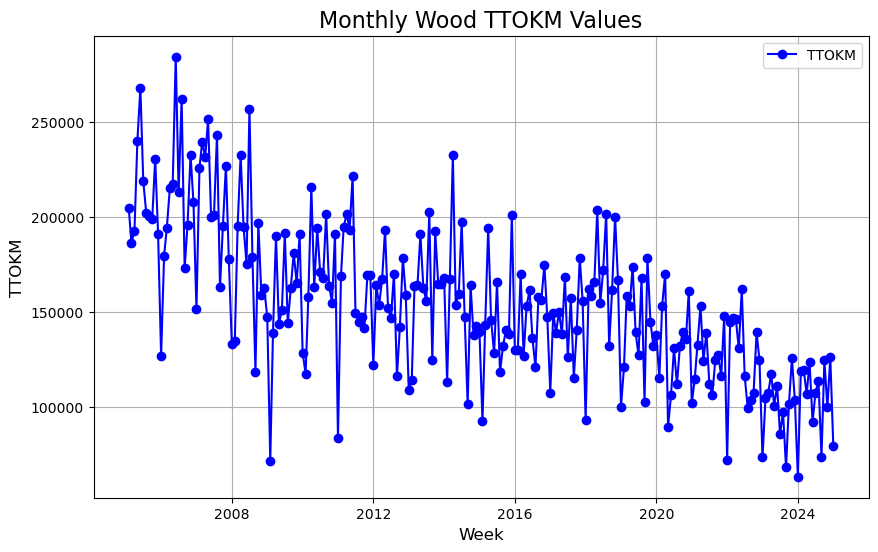

<Figure size 1200x600 with 0 Axes>

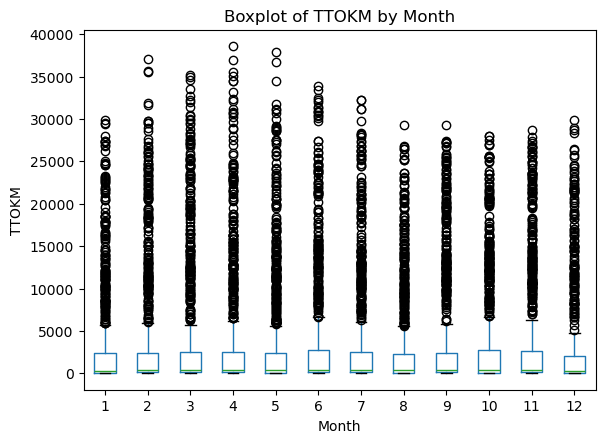

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_grouped.index, monthly_grouped['TTOKM'], marker='o', linestyle='-', color='b', label='TTOKM')
plt.title('Monthly Wood TTOKM Values', fontsize=16)
plt.xlabel('Week', fontsize=12)
plt.ylabel('TTOKM', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

# create a boxplot to visualize the distribution of TTOKM values per month
plt.figure(figsize=(12, 6))
dataset_wood['Month'] = dataset_wood['VERSAND_DATUM'].dt.month
dataset_wood.boxplot(column='TTOKM', by='Month', grid=False)
plt.title('Boxplot of TTOKM by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('TTOKM')
plt.show()

### Decomposing the time series

Time Series is being decomposed here using a seasonal decomposition to understand better the seasonal effects and long-term trends. Additive model is used. The decomposition components include the trend, seasonality and residual. 

In [ ]:
decompose_result = seasonal_decompose(monthly_grouped['TTOKM'], model='additive', period=12)
decompose_result.plot()
plt.show()

### Predicting with PROPHET

Now we are using the predictive model PROPHET, which was developed by Facebook, to make a forecast about the steel transportation volumes.

We start with resetting the index to get the date as a column and rename the columns to match the PROPHET requirements. Then we are ready to create the model. Future dates for predictions - 24 months - are created. The forecast gets generated. A dataframe with actual and predicted values for comparison is generated. Actual test value are added. The metrics for the overlapping period are calculated. Results are plotted. The components get plotted as well.

In [ ]:
prophet_df = monthly_grouped_train.reset_index()
prophet_df.columns = ['ds', 'y']

m = Prophet(yearly_seasonality=True,
           weekly_seasonality=False,
           daily_seasonality=False,
           changepoint_prior_scale=0.03,
           n_changepoints=5,
           
           )
#m.add_country_holidays(country_name='AT')
#m.add_country_holidays(country_name='DE')
#m.add_country_holidays(country_name='CZ')
m.fit(prophet_df)

future = m.make_future_dataframe(periods=24, freq='ME')

forecast = m.predict(future)

forecast_comparison = pd.DataFrame({
    'ds': future['ds'],
    'y_pred': forecast['yhat'],
    'y_pred_lower': forecast['yhat_lower'],
    'y_pred_upper': forecast['yhat_upper']
})

forecast_comparison = forecast_comparison.set_index('ds')
forecast_comparison['y_actual'] = monthly_grouped_test['TTOKM']

overlap_mask = ~forecast_comparison['y_actual'].isna()
mse = ((forecast_comparison[overlap_mask]['y_pred'] - forecast_comparison[overlap_mask]['y_actual'])**2).mean()
rmse = np.sqrt(mse)
mae = (forecast_comparison[overlap_mask]['y_pred'] - forecast_comparison[overlap_mask]['y_actual']).abs().mean()
mape = mean_absolute_percentage_error(forecast_comparison[overlap_mask]['y_pred'],forecast_comparison[overlap_mask]['y_actual'])

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.4f}')

plt.figure(figsize=(15, 7))
plt.plot(forecast_comparison.index, forecast_comparison['y_pred'], label='Predicted', color='blue')
plt.fill_between(forecast_comparison.index, 
                 forecast_comparison['y_pred_lower'], 
                 forecast_comparison['y_pred_upper'], 
                 color='blue', alpha=0.2)
plt.scatter(forecast_comparison.index[overlap_mask], 
           forecast_comparison['y_actual'][overlap_mask], 
           color='red', label='Actual', s=50)
plt.title('Forecast vs Actual Values Steel Monthly')
plt.xlabel('Date')
plt.ylabel('TTOKM')
plt.legend()
plt.grid(True)
fig = m.plot(forecast)
plt.title('Prophet Model - Monthly TTOKM Forecast')
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

### Predicting with SARIMAX

Now we are using the predictive model SARIMAX to make a forecast about the steel transportation volumes.

We apply auto_arima to find the best combination of parameters for our SARIMAX predictive model. 

The best model turns out to be ARIMA(3,1,4)(1,0,2)[12]. Auto arima needed a total fit time of 34.505 seconds to get to these results. 
Explaining the parameters:
(3,1,4)
-> 3 - 3 past values are used for predictions
-> 1 - 1 differencing to make the data stationary
-> 4 - 4 past forecast errors included in the model 

(1,0,2)
-> 1 - one seasonal term
-> 0 - no seasonald ifferencing applied
-> 2 - two past seasonal error included 

[12]
-> seasonality over the period of 12 months observed 

In [ ]:
model = pm.auto_arima(monthly_grouped_train['TTOKM'], seasonal=True, m=12, trace=True, suppress_warnings=True)

### Summary of SARIMAX model results

Next a summary of the SARIMAX model results is generated.

The SARIMAX model used is: (3,1,4) (1,0,2) [12]
The observations are 156. 
The data is monthly.
The measure of model fit is -1461.50 -> the higher the value, the better the fit.

The criteria for model selection used are AIC/BIC/HQIC:
AIC = 2944.901 -> the lower, the better the model
BIC = 2976.100 -> the lower, the better the model
HQIC = 2957.576 -> the lower, the better the model

The coefficients in the autoregressive terms - ar.L1, ar.L2, ar.L3 are mostly negative, which means that there are inverse relationships with past observations.

The coefficients from ma.L1 to ma.L4 are corrections from past steps.

The coefficients in ar.S.L12, ma.S.L12, ma.S.L24 are the seasonality components. For instance, ar.S.L12 shows strong yearly seasonality.

Summary: This SARIMAX Predictive Model captures seasonality well. Some AR (Autoregressive Terms) and MA (Moving Average Terms) terms are not statistically significant.

In [ ]:
sarima_model = SARIMAX(monthly_grouped_train['TTOKM'],
                #exog=test_merge['GDP'],
                order=(3, 1, 4),  
                seasonal_order=(1, 0, 2, 12),  # Added MA term and kept yearly seasonality
                enforce_stationarity=False,  # Allow non-stationary process
                enforce_invertibility=False, # Allow non-invertible process
                #trend='n',  # Removed constant term since we use differencing
                #simple_differencing=True  # Use simple differencing for better performance
                
                )
sarima_result = sarima_model.fit(disp=True)

# Summary of the model
print(sarima_result.summary())

### Plotting next year forecast based on the SARIMAX Predictive Model Results

In [ ]:
# Forecast next year
index_max = len(monthly_grouped_train)
forecast = sarima_result.get_forecast(steps=24)
forecast_index = pd.date_range(monthly_grouped_train.index[index_max-1] + pd.Timedelta(weeks=4), periods=24, freq='ME')
forecast_values = forecast.predicted_mean

# Plot actual data and forecast
plt.figure(figsize=(24, 6))
plt.plot(monthly_grouped_test.index, monthly_grouped_test['TTOKM'], label='Test Data', color='green', marker='o')
total = pd.concat([monthly_grouped, monthly_grouped_test])
#plt.plot(monthly_grouped.index, monthly_grouped['TTOKM'], label='Actual', marker='o')
plt.plot(forecast_index, forecast_values, label='Forecast', color='red', linestyle='--', marker='o')
plt.fill_between(
    forecast_index,
    forecast.conf_int()['lower TTOKM'],
    forecast.conf_int()['upper TTOKM'],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)
plt.title('SARIMA Model - Monthly TTON Forecast (Steel)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('TTON', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### SARIMAX Model Evaluation with Error Metrics such as MSE, RMSE, MAE, MAPE

-> MSE - average squared difference between actual and predicted values
-> RMSE - error range
-> MAE - average absolute difference ebetween actual and predicted values
-> MAPE - average percentage error in predictions

The results we generated suggest:
-> MAPE of 10.27% suggests an accuarte model
-> the RMSE and MAE results, 15 452.11 and 11 627.38 respectively, show prediction errors in the range of 11.000 and 15.000

Next steps: compare these results with the PROPHET results, but try out also LSTM and ETS

In [ ]:
# Calculate evaluation metrics for the SARIMA forecast
actual_values = monthly_grouped_test['TTOKM']
predicted_values = pd.Series(forecast_values, index=forecast_index)

# Calculate metrics for overlapping period
overlap_mask = ~actual_values.isna() & ~predicted_values.isna()
actual_overlap = actual_values[overlap_mask]
pred_overlap = predicted_values[overlap_mask]

mse = ((actual_overlap - pred_overlap) ** 2).mean()
rmse = np.sqrt(mse)
mae = (actual_overlap - pred_overlap).abs().mean()
mape = ((actual_overlap - pred_overlap).abs() / actual_overlap * 100).mean()

print(f'Sarimax Model')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

### Creating a LSTM Predictive Model

In order to be able to create the LSTM Predictive Model, first, we normalize the data, then we convert the time series into sequences, define the sequence length, create the sequences, reshape them to samples, timesteps, and features for LSTM and split the data into train and test datasets. 

-> Normalization of the data contributes to better performance and stability.

-> Converting data into sequences - we do this because we want to define that the past 12 months are used to predict the next one month.

-> We reshape the data so that it fits for LSTM.

-> In this case, we use 90% of the data for training, and 10% for testing. 

In [ ]:
# Normalize the data
scaler = MinMaxScaler()
monthly_grouped['Observed_scaled'] = scaler.fit_transform(monthly_grouped[['TTOKM']])
# Convert time series into sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Define sequence length
SEQ_LENGTH = 12

# Create sequences
X, y = create_sequences(monthly_grouped['Observed_scaled'].values, SEQ_LENGTH)

# Reshape to (samples, timesteps, features) for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split (80-20 split)
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Modeling and Training of the LSTM Predictive Model

Next steps are to create the LSTM Model and to train it.

In [ ]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),  
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16)

### Visualization of LSTM Predictive Model Results

The insights generated by the LSTM model and visualized on this plot indicate that the model shows a smooth trend - it might be even "too smooth" because it seems to not capture so well the dynamic changes. In general, the LSTM provides a stable forecast. 

In [ ]:
y_pred = model.predict(X_test)

# Inverse scale predictions
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create DataFrame for comparison
df_test = monthly_grouped.iloc[split + SEQ_LENGTH:]
df_test['Predicted'] = y_pred_rescaled

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(df_test.index, df_test['TTOKM'], label="Actual", color="red")
plt.plot(df_test.index, df_test['Predicted'], label="LSTM Prediction")
plt.plot(pred_overlap.index, pred_overlap, label="Sarima Prediction")
plt.plot(forecast_comparison.tail(24).index, forecast_comparison.tail(24)['y_pred'], label='Prophet')
plt.legend()
plt.title("LSTM Time Series Forecasting")
plt.show()

### LSTM Model Evaluation with Error Metrics such as RMSE, MAE, MAPE

-> RMSE - error range
-> MAE - average absolute difference ebetween actual and predicted values
-> MAPE - average percentage error in predictions

The results we generated suggest:
-> MAPE of 16.35% suggests a moderately accurate prediction model.
-> the RMSE and MAE results, 22 698.0921 and 16 236.1389 respectively, show prediction errors in the range of 16.000 and 23.000, which can be interpreted as significant deviations from the actual values. 

In [ ]:
# LSTM Model Evaluation
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'MAE: {mae:.4f}')

### Creating a ETS (Exponential Smoothing) Predictive Model

As done for the other models so far - we again adjust the date format. Then we remove the outliers with the IQR method. We use the data 2005-2022 as training data, and 2022-2024 as test data. To ensure smoother forecasting, the data is aggregated on a monthly level. The predictions are generated for two years - 2022-2024. 

We then evaluate the ETS Model by using RMSE, MAE, MAPE:
RMSE = 31188.270907 -> this value shows that the model struggles to capture trendsa ccurately
MAE = 31040.399076 -> this value shows that the model struggles to capture trendsa ccurately
MAPE = 70.738121 -> since MAPE is 50%, this means the model performs poor in forecasting

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data = dataset_wood.copy()
data['Date'] = pd.to_datetime(data['VJA'].astype(str) + '-W' + data['VKW'].astype(str) + '-1', format='%Y-W%W-%w')

# Recalculate outlier bounds using the IQR method
Q1 = data['TTOKM'].quantile(0.25)
Q3 = data['TTOKM'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data[(data['TTOKM'] >= lower_bound) & (data['TTOKM'] <= upper_bound)].copy()

# Split the data into training (2005-2022) and testing (2022-2024)
train_data = data_cleaned[(data_cleaned['Date'] >= '2005-01-01') & (data_cleaned['Date'] < '2022-01-01')]
test_data = data_cleaned[(data_cleaned['Date'] >= '2022-01-01') & (data_cleaned['Date'] < '2024-12-31')]

# Aggregate data by week (summing TTOKM values)
train_series = train_data.groupby([pd.Grouper(key='Date', freq='ME')])['TTOKM'].sum()
test_series = test_data.groupby([pd.Grouper(key='Date', freq='ME')])['TTOKM'].sum()

# Fit Holt-Winters model with a quarterly seasonality (13 weeks per quarter)
hw_model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=12).fit()

# Forecast from 2022 to 2024
forecast_index = pd.date_range(start='2023-01-01', end='2024-12-31', freq='ME')
forecast = hw_model.forecast(len(forecast_index))

# Convert forecast into a DataFrame for display
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecasted_TTOKM': forecast.values})

monthly_test_series = test_series.resample('ME').sum()
monthly_test_series = monthly_test_series[(monthly_test_series.index >= '2023-01-01') & (monthly_test_series.index < '2024-01-01')]


# Ensure the forecasted and actual data are aligned
forecast_df.set_index('Date', inplace=True)

aligned_data = monthly_test_series.to_frame(name='Actual').join(forecast_df['Forecasted_TTOKM'].rename('Forecast'))

# Drop any rows with missing values (if any)
aligned_data.dropna(inplace=True)

# Calculate forecast errors
aligned_data['Error'] = aligned_data['Actual'] - aligned_data['Forecast']
aligned_data['Percentage Error'] = aligned_data['Error'] / aligned_data['Actual'] * 100
aligned_data['Absolute Error'] = aligned_data['Error'].abs()
aligned_data['Absolute Percentage Error'] = aligned_data['Absolute Error'] / aligned_data['Actual'] * 100

# Mean Error (ME)
ME = aligned_data['Error'].mean()

# Root Mean Squared Error (RMSE)
RMSE = np.sqrt((aligned_data['Error'] ** 2).mean())

# Mean Absolute Error (MAE)
MAE = aligned_data['Absolute Error'].mean()

# Mean Percentage Error (MPE)
MPE = aligned_data['Percentage Error'].mean()

# Mean Absolute Percentage Error (MAPE)
MAPE = aligned_data['Absolute Percentage Error'].mean()

# Mean Absolute Scaled Error (MASE)
# Calculate in-sample naive forecast errors (lagged by one period)
naive_forecast = aligned_data['Actual'].shift(1)
naive_errors = aligned_data['Actual'] - naive_forecast
naive_MAE = naive_errors.abs().mean()
MASE = MAE / naive_MAE

# Root Mean Squared Scaled Error (RMSSE)
naive_RMSE = np.sqrt((naive_errors ** 2).mean())
RMSSE = RMSE / naive_RMSE

# Autocorrelation of errors at lag 1 (ACF1)
ACF1 = acf(aligned_data['Error'], nlags=1)[1]

# Display the results
metrics = {
    'Mean Error (ME)': ME,
    'Root Mean Squared Error (RMSE)': RMSE,
    'Mean Absolute Error (MAE)': MAE,
    'Mean Percentage Error (MPE)': MPE,
    'Mean Absolute Percentage Error (MAPE)': MAPE,
    'Mean Absolute Scaled Error (MASE)': MASE,
    'Root Mean Squared Scaled Error (RMSSE)': RMSSE,
    'Autocorrelation of errors at lag 1 (ACF1)': ACF1
}

# Convert metrics to a DataFrame for better readability
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print(metrics_df)

### Comparing all four predictive models and plotting a visual of this comparison

In [ ]:
# Convert forecast into a DataFrame for display
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecasted_TTOKM': forecast.values})

# Plot actual vs predicted values
plt.figure(figsize=(18, 7))
plt.plot(actual_overlap.index, actual_overlap, label='Actual', marker='o')
plt.plot(pred_overlap.index, pred_overlap, label='Sarimax', marker='o')
plt.plot(df_test.index, df_test['Predicted'], label="LSTM Prediction",  marker='o')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_TTOKM'], label='Holt-Winters', marker='o')
plt.plot(forecast_comparison.tail(24).index, forecast_comparison.tail(24)['y_pred'], label='Prophet', marker='o')
plt.title('SARIMA, Prophet, Holt-Winters and LSTM Model: Actual vs Predicted Values (Steel)')
plt.xlabel('Date')
plt.ylabel('TTOKM')
plt.legend()
plt.grid(True)
plt.show()

### Creating the Predictive Models about the commodity Mineral Oil

The data is loaded. All CSV files are read and merged into one dataframe. A customized data column is generated - the year and week columns are joined into a string, a datatime format "%Y%W%w" is created, the first week day is identified.

The dataset is split into a training and testing sets.

In [ ]:
# List all files in the data folder
data_folder = './data/moil_2'
files = [f for f in os.listdir(data_folder) if f.endswith('2024.csv')]

# Read and concatenate all CSV files
dataset = pd.concat([pd.read_csv(os.path.join(data_folder, f), sep=',') for f in files])

dataset['VJA_VKW'] = dataset['VJA'].astype(str) + dataset['VKW'].astype(str) + '1'
dataset['VERSAND_DATUM'] = pd.to_datetime(dataset['VJA_VKW'], format='%Y%W%w')

# Filter rows with VERSAND_DATUM between '2012-01-01' and '2022-12-31'
dataset['VERSAND_DATUM'] = pd.to_datetime(dataset['VERSAND_DATUM'])
dataset_test = dataset[(dataset['VERSAND_DATUM'] >= '2023-01-01') & (dataset['VERSAND_DATUM'] <= '2024-12-31')]
dataset_train = dataset[(dataset['VERSAND_DATUM'] >= '2010-01-01') & (dataset['VERSAND_DATUM'] <= '2022-12-31')]

### Grouping data for Time Series Analysis

Grouping data by month. Then apply the groupign tot he different datasets - train and test. This helps identifying the monthly trends. 

In [ ]:
# Group by month and NHM_NR_ORIGINAL
monthly_moil_grouped = dataset.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()
monthly_grouped_train = dataset_train.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()
monthly_grouped_test = dataset_test.groupby([pd.Grouper(key='VERSAND_DATUM', freq='ME')])[['TTOKM']].sum()

### Creating a visualization of the Mineral Oil transportation volumes on a monthly basis in TTOKM values

The data relates to the peridos 2005-2024. On the X-axes the months are represented, on the Y-axes the TTOKM (total shipment distance) values' range is represented. This plot is very useful for identifying the trends and seasonal patterns. 

In [ ]:
# Plot the Monthly values
plt.figure(figsize=(10, 6))
plt.plot(monthly_moil_grouped.index, monthly_moil_grouped['TTOKM'], marker='o', linestyle='-', color='b', label='TTOKM')
plt.title('Monthly TTOKM Values', fontsize=16)
plt.xlabel('Week', fontsize=12)
plt.ylabel('TTOKM', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

### Decomposing the time series

Time Series is being decomposed here using a seasonal decomposition to understand better the seasonal effects and long-term trends. Additive model is used. The decomposition components include the trend, seasonality and residual. 

In [ ]:
# Decompose the time series
decompose_result = seasonal_decompose(monthly_moil_grouped['TTOKM'], model='additive', period=12)
decompose_result.plot()
plt.show()

### Predicting with PROPHET

Now we are using the predictive model PROPHET, which was developed by Facebook, to make a forecast about the steel transportation volumes.

We start with resetting the index to get the date as a column and rename the columns to match the PROPHET requirements. Then we are ready to create the model. Future dates for predictions - 24 months - are created. The forecast gets generated. A dataframe with actual and predicted values for comparison is generated. Actual test value are added. The metrics for the overlapping period are calculated. Results are plotted. The components get plotted as well.

In [ ]:
# Reset index to get date as a column and rename columns to match Prophet requirements
prophet_df = monthly_grouped_train.reset_index()
prophet_df.columns = ['ds', 'y']

# Create and fit Prophet model
m = Prophet(yearly_seasonality=True,
           weekly_seasonality=False,
           daily_seasonality=False,
           changepoint_prior_scale=0.03,
           n_changepoints=5,
           
           )
#m.add_country_holidays(country_name='AT')
#m.add_country_holidays(country_name='DE')
#m.add_country_holidays(country_name='CZ')
m.fit(prophet_df)

# Create future dates for prediction (52 weeks of 2018)
future = m.make_future_dataframe(periods=24, freq='ME', include_history=True)

# Make predictions
forecast = m.predict(future)

# Create dataframe with actual and predicted values for comparison
forecast_comparison = pd.DataFrame({
    'ds': future['ds'],
    'y_pred': forecast['yhat'],
    'y_pred_lower': forecast['yhat_lower'],
    'y_pred_upper': forecast['yhat_upper']
})

# Add actual test values
forecast_comparison = forecast_comparison.set_index('ds')
forecast_comparison['y_actual'] = monthly_grouped_test['TTOKM']

# Calculate metrics for the overlapping period
overlap_mask = ~forecast_comparison['y_actual'].isna()
mse = ((forecast_comparison[overlap_mask]['y_pred'] - forecast_comparison[overlap_mask]['y_actual'])**2).mean()
rmse = np.sqrt(mse)
mae = (forecast_comparison[overlap_mask]['y_pred'] - forecast_comparison[overlap_mask]['y_actual']).abs().mean()
mape = mean_absolute_percentage_error(forecast_comparison[overlap_mask]['y_pred'],forecast_comparison[overlap_mask]['y_actual'])

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.4f}')
# Plot the results
plt.figure(figsize=(15, 7))
plt.plot(forecast_comparison.index, forecast_comparison['y_pred'], label='Predicted', color='blue')
plt.fill_between(forecast_comparison.index, 
                 forecast_comparison['y_pred_lower'], 
                 forecast_comparison['y_pred_upper'], 
                 color='blue', alpha=0.2)
plt.scatter(forecast_comparison.index[overlap_mask], 
           forecast_comparison['y_actual'][overlap_mask], 
           color='red', label='Actual', s=50)
plt.title('Forecast vs Actual Values')
plt.xlabel('Date')
plt.ylabel('TTOKM')
plt.legend()
plt.grid(True)
fig = m.plot(forecast)
plt.title('Prophet Model - Weekly TTOKM Forecast')
plt.show()

# Plot components
fig2 = m.plot_components(forecast)
plt.show()

### Predicting with SARIMAX

Now we are using the predictive model SARIMAX to make a forecast about the mineral oil transportation volumes.

We apply auto_arima to find the best combination of parameters for our SARIMAX predictive model. 

The best model turns out to be ARIMA(2,1,3)(1,0,0)[12]. Auto arima needed a total fit time of 10.267 seconds to get to these results. 
Explaining the parameters:
(2,1,3)
-> 2 - 2 past values are used for predictions
-> 1 - 1 differencing to make the data stationary
-> 3 - 3 past forecast errors included in the model 

(1,0,0)
-> 1 - one seasonal term
-> 0 - no seasonald ifferencing applied
-> 0 - two past seasonal error included 

[12]
-> seasonality over the period of 12 months observed 

In [ ]:
model = pm.auto_arima(monthly_grouped_train, seasonal=True, m=12, trace=True, suppress_warnings=True)

### Summary of SARIMAX model results

Next a summary of the SARIMAX model results is generated.

The SARIMAX model used is: (2,1,3) (1,0,0) [12]
The data is monthly.
The measure of model fit is -1551.607 -> the higher the value, the better the fit.

The criteria for model selection used are AIC/BIC/HQIC:
AIC = 3117.214 -> the lower, the better the model
BIC = 3137.856 -> the lower, the better the model
HQIC = 3125.602 -> the lower, the better the model

The coefficients in the autoregressive terms - ar.L1, ar.L2 are mostly negative, which means that there are inverse relationships with past observations.

The coefficients from ma.L1 to ma.L3 are corrections from past steps.

The coefficients in ar.S.L12 is the seasonality component. For instance, ar.S.L12 shows strong yearly seasonality.

Summary: This SARIMAX Predictive Model captures seasonality well. 

In [ ]:
sarima_model = SARIMAX(monthly_grouped_train['TTOKM'],
                #exog=test_merge['GDP'],
                order=(2, 1, 3),  
                seasonal_order=(1, 0, 0, 12),  # Added MA term and kept yearly seasonality
                enforce_stationarity=False,  # Allow non-stationary process
                enforce_invertibility=False, # Allow non-invertible process
                #trend='n',  # Removed constant term since we use differencing
                #simple_differencing=True  # Use simple differencing for better performance
                
                )
sarima_result = sarima_model.fit(disp=True)

# Summary of the model
print(sarima_result.summary())

### Plotting next year forecast based on the SARIMAX Predictive Model Results

In [ ]:
# Forecast next year
index_max = len(monthly_grouped_train)
forecast = sarima_result.get_forecast(steps=24)
forecast_index = pd.date_range(monthly_grouped_train.index[index_max-1] + pd.Timedelta(weeks=4), periods=24, freq='ME')
forecast_values = forecast.predicted_mean

# Plot actual data and forecast
plt.figure(figsize=(24, 6))
plt.plot(monthly_grouped_test.index, monthly_grouped_test['TTOKM'], label='Test Data', color='green', marker='o')
total = pd.concat([monthly_moil_grouped, monthly_grouped_test])
#plt.plot(weekly_grouped.index, weekly_grouped['TTOKM'], label='Actual', marker='o')
plt.plot(forecast_index, forecast_values, label='Forecast', color='red', linestyle='--', marker='o')
plt.fill_between(
    forecast_index,
    forecast.conf_int()['lower TTOKM'],
    forecast.conf_int()['upper TTOKM'],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)
plt.title('SARIMA Model - Monthly TTON Forecast (MOil)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('TTON', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

#Evaluatation of the model

RMSE suggests that the model captures well trends
MAE suggests also that the model captures well trends
MAPE suggests that the forecastign accuarcy is relatively good

In [ ]:
# Calculate evaluation metrics for the SARIMA forecast
actual_values = monthly_grouped_test['TTOKM']
predicted_values = pd.Series(forecast_values, index=forecast_index)

# Calculate metrics for overlapping period
overlap_mask = ~actual_values.isna() & ~predicted_values.isna()
actual_overlap = actual_values[overlap_mask]
pred_overlap = predicted_values[overlap_mask]

mse = ((actual_overlap - pred_overlap) ** 2).mean()
rmse = np.sqrt(mse)
mae = (actual_overlap - pred_overlap).abs().mean()
mape = ((actual_overlap - pred_overlap).abs() / actual_overlap * 100).mean()

print(f'Sarimax Model')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2f}%')



### Creating a LSTM Predictive Model

In order to be able to create the LSTM Predictive Model, first, we normalize the data, then we convert the time series into sequences, define the sequence length, create the sequences, reshape them to samples, timesteps, and features for LSTM and split the data into train and test datasets. 

-> Normalization of the data contributes to better performance and stability.

-> Converting data into sequences - we do this because we want to define that the past 12 months are used to predict the next one month.

-> We reshape the data so that it fits for LSTM.

-> In this case, we use 90% of the data for training, and 10% for testing. 

In [ ]:
# Normalize the data
scaler = MinMaxScaler()
monthly_moil_grouped['Observed_scaled'] = scaler.fit_transform(monthly_moil_grouped[['TTOKM']])
#weekly_grouped_test['Observed_scaled'] = scaler.fit_transform(weekly_grouped_test[['TTOKM']])
# Convert time series into sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Define sequence length
SEQ_LENGTH = 12

# Create sequences
X, y = create_sequences(monthly_moil_grouped['Observed_scaled'].values, SEQ_LENGTH)

# Reshape to (samples, timesteps, features) for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-test split (80-20 split)
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### We create the LSTM model and train it

In [ ]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),  
    LSTM(50, return_sequences=False),
    Dense(25, activation="relu"),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=16)

### Visualizing the LSTM results

In [ ]:
y_pred = model.predict(X_test)

# Inverse scale predictions
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create DataFrame for comparison
df_test = monthly_moil_grouped.iloc[split + SEQ_LENGTH:]
df_test['Predicted'] = y_pred_rescaled

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(df_test.index, df_test['TTOKM'], label="Actual", color="red")
plt.plot(df_test.index, df_test['Predicted'], label="LSTM Prediction")
plt.plot(pred_overlap.index, pred_overlap, label="Sarima Prediction")
plt.plot(forecast_comparison.tail(24).index, forecast_comparison.tail(24)['y_pred'], label='Prophet')
plt.legend()
plt.title("LSTM Time Series Forecasting")
plt.show()

### Evaluation of the LSTM model

Low RMSE and MAE suggest good mdoel performance
MAPE of 10% suggests the model predictions are accurate

In [ ]:
# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'MAE: {mae:.4f}')

### Creating a ETS (Exponential Smoothing) Predictive Model

As done for the other models so far - we again adjust the date format. Then we remove the outliers with the IQR method. We use the data 2005-2022 as training data, and 2022-2024 as test data. To ensure smoother forecasting, the data is aggregated on a monthly level. The predictions are generated for two years - 2022-2024. 

We then evaluate the ETS Model by using RMSE, MAE, MAPE:
RMSE = 28195.909376 -> this value shows that the model struggles to capture trends accurately
MAE = 28085.035955 -> this value shows that the model struggles to capture trends accurately
MAPE = 67.635395 -> since MAPE is 50%, this means the model performs poor in forecasting

In [ ]:
data = dataset.copy()
data['Date'] = pd.to_datetime(data['VJA'].astype(str) + '-W' + data['VKW'].astype(str) + '-1', format='%Y-W%W-%w')

# Recalculate outlier bounds using the IQR method
Q1 = data['TTOKM'].quantile(0.25)
Q3 = data['TTOKM'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned = data[(data['TTOKM'] >= lower_bound) & (data['TTOKM'] <= upper_bound)].copy()

# Split the data into training (2005-2020) and testing (2020-2024)
train_data = data_cleaned[(data_cleaned['Date'] >= '2005-01-01') & (data_cleaned['Date'] < '2023-01-01')]
test_data = data_cleaned[(data_cleaned['Date'] >= '2023-01-01') & (data_cleaned['Date'] < '2024-01-01')]

# Aggregate data by week (summing TTOKM values)
train_series = train_data.groupby([pd.Grouper(key='Date', freq='ME')])['TTOKM'].sum()
test_series = test_data.groupby([pd.Grouper(key='Date', freq='ME')])['TTOKM'].sum()

# Fit Holt-Winters model with a quarterly seasonality (13 weeks per quarter)
hw_model = ExponentialSmoothing(train_series, trend='add', seasonal='add', seasonal_periods=12).fit()

# Forecast from 2022 to 2024
forecast_index = pd.date_range(start='2023-01-01', end='2024-12-31', freq='ME')
forecast = hw_model.forecast(len(forecast_index))

# Convert forecast into a DataFrame for display
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecasted_TTOKM': forecast.values})

# Ensure the forecasted and actual data are aligned
forecast_df.set_index('Date', inplace=True)
aligned_data = monthly_test_series.to_frame(name='Actual').join(forecast_df['Forecasted_TTOKM'].rename('Forecast'))

# Drop any rows with missing values (if any)
aligned_data.dropna(inplace=True)

# Calculate forecast errors
aligned_data['Error'] = aligned_data['Actual'] - aligned_data['Forecast']
aligned_data['Percentage Error'] = aligned_data['Error'] / aligned_data['Actual'] * 100
aligned_data['Absolute Error'] = aligned_data['Error'].abs()
aligned_data['Absolute Percentage Error'] = aligned_data['Absolute Error'] / aligned_data['Actual'] * 100

# Mean Error (ME)
ME = aligned_data['Error'].mean()

# Root Mean Squared Error (RMSE)
RMSE = np.sqrt((aligned_data['Error'] ** 2).mean())

# Mean Absolute Error (MAE)
MAE = aligned_data['Absolute Error'].mean()

# Mean Percentage Error (MPE)
MPE = aligned_data['Percentage Error'].mean()

# Mean Absolute Percentage Error (MAPE)
MAPE = aligned_data['Absolute Percentage Error'].mean()

# Mean Absolute Scaled Error (MASE)
# Calculate in-sample naive forecast errors (lagged by one period)
naive_forecast = aligned_data['Actual'].shift(1)
naive_errors = aligned_data['Actual'] - naive_forecast
naive_MAE = naive_errors.abs().mean()
MASE = MAE / naive_MAE

# Root Mean Squared Scaled Error (RMSSE)
naive_RMSE = np.sqrt((naive_errors ** 2).mean())
RMSSE = RMSE / naive_RMSE

# Autocorrelation of errors at lag 1 (ACF1)
ACF1 = acf(aligned_data['Error'], nlags=1)[1]
# Display the results
metrics = {
    'Mean Error (ME)': ME,
    'Root Mean Squared Error (RMSE)': RMSE,
    'Mean Absolute Error (MAE)': MAE,
    'Mean Percentage Error (MPE)': MPE,
    'Mean Absolute Percentage Error (MAPE)': MAPE,
    'Mean Absolute Scaled Error (MASE)': MASE,
    'Root Mean Squared Scaled Error (RMSSE)': RMSSE,
    'Autocorrelation of errors at lag 1 (ACF1)': ACF1
}

# Convert metrics to a DataFrame for better readability
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
print(metrics_df)


### Visualization and comparison of the four predictive models for the commodity mineral oil

In [ ]:
# Convert forecast into a DataFrame for display
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecasted_TTOKM': forecast.values})

# Plot actual vs predicted values
plt.figure(figsize=(18, 7))
plt.plot(actual_overlap.index, actual_overlap, label='Actual', marker='o')
plt.plot(pred_overlap.index, pred_overlap, label='Sarimax', marker='o')
plt.plot(df_test.index, df_test['Predicted'], label="LSTM Prediction",  marker='o')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_TTOKM'], label='Holt-Winters', marker='o')
plt.plot(forecast_comparison.tail(24).index, forecast_comparison.tail(24)['y_pred'], label='Prophet', marker='o')
plt.title('SARIMA, Prophet, Holt-Winters and LSTM Model: Actual vs Predicted Values (MOIL)')
plt.xlabel('Date')
plt.ylabel('TTOKM')
plt.legend()
plt.grid(True)
plt.show()